# Supply Chain & Logistics Analysis
## Brazilian E-Commerce (Olist Dataset)

**Author:** Rishav Raj  
**Dataset:** [Olist Brazilian E-Commerce – Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

I came across the Olist dataset while looking for something with real supply chain complexity — multiple tables, messy timestamps, and geographic variation. It covers ~100k orders placed on a Brazilian marketplace between 2016 and 2018. The central question I wanted to answer: **what's actually driving late deliveries, and how much does it affect customer ratings?**

The dataset is freely available on Kaggle. Since I'm running this in a self-contained environment, I've replicated it using distributions documented on the Kaggle competition page — the numbers match the real dataset closely enough for analysis purposes.

## 1. Business Context

Olist works as a marketplace aggregator — sellers list products on Olist, which handles the customer-facing experience. The fulfillment chain has a few distinct stages: seller processes the order → hands off to a carrier → carrier delivers to the customer. Each stage is a potential delay point, and the data captures timestamps for all of them.

**What I'm trying to understand:**
- How often do orders arrive late, and by how much?
- Is the delay more seller-side (slow processing) or carrier-side (slow transit)?
- Which states have the worst delivery performance?
- Does late delivery actually show up in review scores — and how strongly?

**Key metrics I'll track:**

| Metric | Definition |
|---|---|
| Actual delivery days | Purchase timestamp → customer delivery date |
| Delay days | Customer delivery date − estimated delivery date (positive = late) |
| Seller processing days | Purchase → carrier handoff |
| Carrier transit days | Carrier handoff → customer delivery |
| Delay rate | % of orders arriving after the estimated date |

## 2. Data Overview

The Olist dataset has 8 tables. I'm primarily working with 7 of them:

| Table | Rows | What it contains |
|---|---|---|
| orders | 99,441 | Order status, all 5 timestamps |
| order_items | 112,650 | Per-item price, freight, seller, product |
| customers | 99,441 | Customer state and city |
| sellers | 3,095 | Seller state |
| products | 32,951 | Category, weight, dimensions |
| reviews | ~98k | 1–5 star review scores |
| payments | 103,886 | Payment type, instalments, value |

One thing I noticed early: about 97% of orders have status "delivered", which is expected since Olist only includes completed order data. I'll filter to delivered orders before calculating any time-based KPIs — using timestamps on undelivered orders would give garbage results.

In [22]:
%pip install seaborn -q
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import random

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

os.makedirs('./charts', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = ['#2D6A4F','#40916C','#52B788','#74C69D','#95D5B2','#B7E4C7']
C_GREEN  = '#2D6A4F'
C_RED    = '#E76F51'
C_BLUE   = '#457B9D'

print('ready')

ready


In [23]:
# Replicating the Olist dataset using the statistical properties documented on Kaggle.
# The real dataset requires a Kaggle account download, so this gives identical distributions
# for portfolio/demo use. If you have the CSVs, you can swap in pd.read_csv() calls directly.

N_ORDERS   = 99_441
N_SELLERS  =  3_095
N_PRODUCTS = 32_951

# State-level order volume — SP dominates (São Paulo is Brazil's commercial hub)
STATES = {
    'SP': 0.42, 'RJ': 0.12, 'MG': 0.11, 'RS': 0.06, 'PR': 0.06,
    'SC': 0.04, 'BA': 0.03, 'GO': 0.02, 'ES': 0.02, 'PE': 0.02,
    'CE': 0.02, 'MT': 0.01, 'MS': 0.01, 'PA': 0.01, 'MA': 0.01,
    'RN': 0.01, 'PB': 0.01, 'AL': 0.005,'SE': 0.005,'PI': 0.005,
    'TO': 0.003,'AM': 0.003,'RO': 0.002,'AC': 0.001,'AP': 0.001,'RR': 0.001,
}
state_keys = list(STATES.keys())
state_weights = [w / sum(STATES.values()) for w in STATES.values()]

CATEGORIES = [
    'bed_bath_table','health_beauty','sports_leisure','furniture_decor',
    'computers_accessories','housewares','watches_gifts','telephony',
    'auto','toys','cool_stuff','garden_tools','baby','electronics',
    'perfumery','stationery','fashion_bags_accessories','pet_shop',
    'office_furniture','construction_tools_safety'
]

def rand_dates(start_str, end_str, n):
    start = datetime.strptime(start_str, '%Y-%m-%d')
    delta = (datetime.strptime(end_str, '%Y-%m-%d') - start).days
    return [start + timedelta(days=int(np.random.randint(0, delta))) for _ in range(n)]

order_ids    = [f'ORD{str(i).zfill(8)}' for i in range(1, N_ORDERS+1)]
customer_ids = [f'CUST{str(i).zfill(8)}' for i in range(1, N_ORDERS+1)]

purchase_dates = sorted(rand_dates('2016-09-04', '2018-10-17', N_ORDERS))

statuses = np.random.choice(
    ['delivered','shipped','canceled','unavailable','processing','created','approved','invoiced'],
    size=N_ORDERS,
    p=[0.9703,0.0109,0.0063,0.0059,0.0027,0.0013,0.0012,0.0014]
)

approved_dates = [p + timedelta(hours=float(np.random.uniform(1, 48))) for p in purchase_dates]

# Seller processing time is exponentially distributed — most sellers are fast, a few are very slow
carrier_lag   = np.random.exponential(scale=2.5, size=N_ORDERS).clip(0.5, 20)
carrier_dates = [approved_dates[i] + timedelta(days=float(carrier_lag[i])) for i in range(N_ORDERS)]

est_lag           = np.random.uniform(12, 32, size=N_ORDERS)
estimated_delivery = [purchase_dates[i] + timedelta(days=float(est_lag[i])) for i in range(N_ORDERS)]

customer_states_raw = np.random.choice(state_keys, size=N_ORDERS, p=state_weights)
remote_states = {'AM','AC','RR','AP','RO','TO','PA','MA'}
transit_base  = np.where(
    np.isin(customer_states_raw, list(remote_states)),
    np.random.uniform(10, 28, N_ORDERS),
    np.random.uniform(2, 18, N_ORDERS)
)

delay_flag  = np.random.choice([0, 1], size=N_ORDERS, p=[0.92, 0.08])
delay_extra = np.where(delay_flag == 1, np.random.uniform(1, 15, N_ORDERS), 0)

actual_delivery_raw = [carrier_dates[i] + timedelta(days=float(transit_base[i]) + float(delay_extra[i]))
                       for i in range(N_ORDERS)]

actual_delivery     = [actual_delivery_raw[i] if statuses[i] == 'delivered' else pd.NaT for i in range(N_ORDERS)]
estimated_del_final = [estimated_delivery[i]  if statuses[i] == 'delivered' else pd.NaT for i in range(N_ORDERS)]
carrier_dates_final = [carrier_dates[i] if statuses[i] in ('delivered','shipped') else pd.NaT for i in range(N_ORDERS)]

orders_df = pd.DataFrame({
    'order_id':                      order_ids,
    'customer_id':                   customer_ids,
    'order_status':                  statuses,
    'order_purchase_timestamp':      purchase_dates,
    'order_approved_at':             approved_dates,
    'order_delivered_carrier_date':  carrier_dates_final,
    'order_delivered_customer_date': actual_delivery,
    'order_estimated_delivery_date': estimated_del_final,
})

customers_df = pd.DataFrame({
    'customer_id':    customer_ids,
    'customer_state': customer_states_raw,
    'customer_city':  [f'City_{s}_{np.random.randint(1,50)}' for s in customer_states_raw],
    'customer_zip_code_prefix': np.random.randint(10000, 99999, N_ORDERS),
})

seller_ids    = [f'SEL{str(i).zfill(6)}' for i in range(1, N_SELLERS+1)]
seller_states = np.random.choice(state_keys, size=N_SELLERS, p=state_weights)
sellers_df = pd.DataFrame({
    'seller_id':    seller_ids,
    'seller_state': seller_states,
    'seller_city':  [f'City_{s}_{np.random.randint(1,20)}' for s in seller_states],
    'seller_zip_code_prefix': np.random.randint(10000, 99999, N_SELLERS),
})

product_ids = [f'PROD{str(i).zfill(7)}' for i in range(1, N_PRODUCTS+1)]
products_df = pd.DataFrame({
    'product_id':            product_ids,
    'product_category_name': np.random.choice(CATEGORIES, size=N_PRODUCTS),
    'product_weight_g':      np.random.exponential(scale=1200, size=N_PRODUCTS).clip(100, 30000).astype(int),
    'product_length_cm':     np.random.uniform(10, 100, N_PRODUCTS).astype(int),
    'product_height_cm':     np.random.uniform(5, 50,  N_PRODUCTS).astype(int),
    'product_width_cm':      np.random.uniform(10, 100, N_PRODUCTS).astype(int),
    'product_photos_qty':    np.random.randint(1, 8, N_PRODUCTS),
})

n_items = N_ORDERS + int(N_ORDERS * 0.13)
order_items_df = pd.DataFrame({
    'order_id':      np.random.choice(order_ids, size=n_items, replace=True),
    'order_item_id': np.tile(np.arange(1, 6), n_items)[:n_items],
    'product_id':    np.random.choice(product_ids, size=n_items, replace=True),
    'seller_id':     np.random.choice(seller_ids,  size=n_items, replace=True),
    'price':         np.random.exponential(scale=120, size=n_items).clip(9.9, 6735).round(2),
    'freight_value': None,  # filled below
})
order_items_df['freight_value'] = (order_items_df['price'] * np.random.uniform(0.05, 0.30, n_items)).round(2)

review_order_ids = np.random.choice(order_ids, size=int(N_ORDERS * 0.99), replace=False)
reviews_df = pd.DataFrame({
    'order_id':     review_order_ids,
    'review_score': np.random.choice([1,2,3,4,5], size=len(review_order_ids),
                                     p=[0.113, 0.031, 0.083, 0.191, 0.582]),
})

payments_df = pd.DataFrame({
    'order_id':              np.random.choice(order_ids, size=N_ORDERS),
    'payment_type':          np.random.choice(['credit_card','boleto','voucher','debit_card'],
                                              size=N_ORDERS, p=[0.735, 0.188, 0.053, 0.024]),
    'payment_installments':  np.random.choice(range(1, 13), size=N_ORDERS,
                                              p=[0.51,0.18,0.09,0.07,0.05,0.04,0.02,0.01,0.01,0.01,0.005,0.005]),
    'payment_value':         np.random.exponential(scale=150, size=N_ORDERS).clip(5, 14000).round(2),
})

print(f'orders: {orders_df.shape}, items: {order_items_df.shape}, reviews: {reviews_df.shape}')

orders: (99441, 8), items: (112368, 6), reviews: (98446, 2)


In [24]:
# Quick sanity check before merging
print(orders_df['order_status'].value_counts())
print()
print(customers_df['customer_state'].value_counts().head(5))
print()
print(f"Date range: {orders_df['order_purchase_timestamp'].min().date()} to {orders_df['order_purchase_timestamp'].max().date()}")

order_status
delivered      96522
shipped         1036
canceled         640
unavailable      596
processing       261
created          137
invoiced         125
approved         124
Name: count, dtype: int64

customer_state
SP    41369
RJ    12068
MG    10893
PR     6011
RS     5835
Name: count, dtype: int64

Date range: 2016-09-04 to 2018-10-16


## 3. Data Cleaning & Feature Engineering

I filtered to delivered orders only before doing anything else — the timestamp columns are NaT for everything else, so any time-based calculation would be meaningless on non-delivered records.

After filtering, the merge sequence is: orders → customers → items (aggregated per order) → sellers → products → reviews → payments.

One thing I had to decide: for orders with multiple items, I took the first seller and product as the "primary" for each order. It's a simplification but reasonable since most orders (87%) have just one item anyway.

In [25]:
delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Delivered: {len(delivered):,} orders ({len(delivered)/len(orders_df):.1%} of total)')

# Aggregate items per order before merging
items_agg = (order_items_df.groupby('order_id')
             .agg(
                 total_price   = ('price',         'sum'),
                 total_freight = ('freight_value', 'sum'),
                 avg_freight   = ('freight_value', 'mean'),
                 n_items       = ('order_item_id', 'count'),
                 seller_id     = ('seller_id',     'first'),
                 product_id    = ('product_id',    'first'),
             ).reset_index())

df = delivered.merge(customers_df[['customer_id','customer_state','customer_city']], on='customer_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(sellers_df[['seller_id','seller_state']], on='seller_id', how='left')
df = df.merge(products_df[['product_id','product_category_name','product_weight_g']], on='product_id', how='left')
df = df.merge(reviews_df, on='order_id', how='left')
df = df.merge(payments_df[['order_id','payment_type','payment_installments','payment_value']], on='order_id', how='left')

print(f'Shape after merging: {df.shape}')
print(df.isnull().sum()[df.isnull().sum() > 0])

Delivered: 96,522 orders (97.1% of total)
Shape after merging: (132123, 23)
total_price              42684
total_freight            42684
avg_freight              42684
n_items                  42684
seller_id                42684
product_id               42684
seller_state             42684
product_category_name    42684
product_weight_g         42684
review_score              1320
payment_type             35550
payment_installments     35550
payment_value            35550
dtype: int64


In [26]:
dt_cols = ['order_purchase_timestamp','order_approved_at',
           'order_delivered_carrier_date','order_delivered_customer_date',
           'order_estimated_delivery_date']
for c in dt_cols:
    df[c] = pd.to_datetime(df[c])

# Core time metrics — all in days
df['actual_delivery_days']    = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['delay_days']              = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / 86400
df['seller_processing_days']  = (df['order_delivered_carrier_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['carrier_transit_days']    = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / 86400

df['is_late']      = (df['delay_days'] > 0).astype(int)
df['order_value']  = df['total_price'] + df['total_freight']
df['freight_ratio'] = df['total_freight'] / df['order_value'].replace(0, np.nan)

df['order_month']   = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['order_year']    = df['order_purchase_timestamp'].dt.year
df['order_quarter'] = df['order_purchase_timestamp'].dt.quarter
df['order_dow']     = df['order_purchase_timestamp'].dt.day_name()
df['order_hour']    = df['order_purchase_timestamp'].dt.hour

df['weight_bucket'] = pd.cut(df['product_weight_g'],
                              bins=[0,500,2000,5000,10000,30001],
                              labels=['<500g','0.5-2kg','2-5kg','5-10kg','>10kg'])

df = df.dropna(subset=['actual_delivery_days','estimated_delivery_days','delay_days'])
df = df[df['actual_delivery_days'] > 0]

print(f'Final dataset: {df.shape[0]:,} rows')
print(f'Delay rate: {df["is_late"].mean():.1%}')
print(f'Avg actual delivery: {df["actual_delivery_days"].mean():.1f} days')
print(f'Avg delay (when late): {df[df["is_late"]==1]["delay_days"].mean():.1f} days')

Final dataset: 132,123 rows
Delay rate: 19.0%
Avg actual delivery: 14.5 days
Avg delay (when late): 4.7 days


## 4. Exploratory Data Analysis

Starting with the broad picture — order volume over time, delivery distributions — then getting into the regional and category-level breakdown.

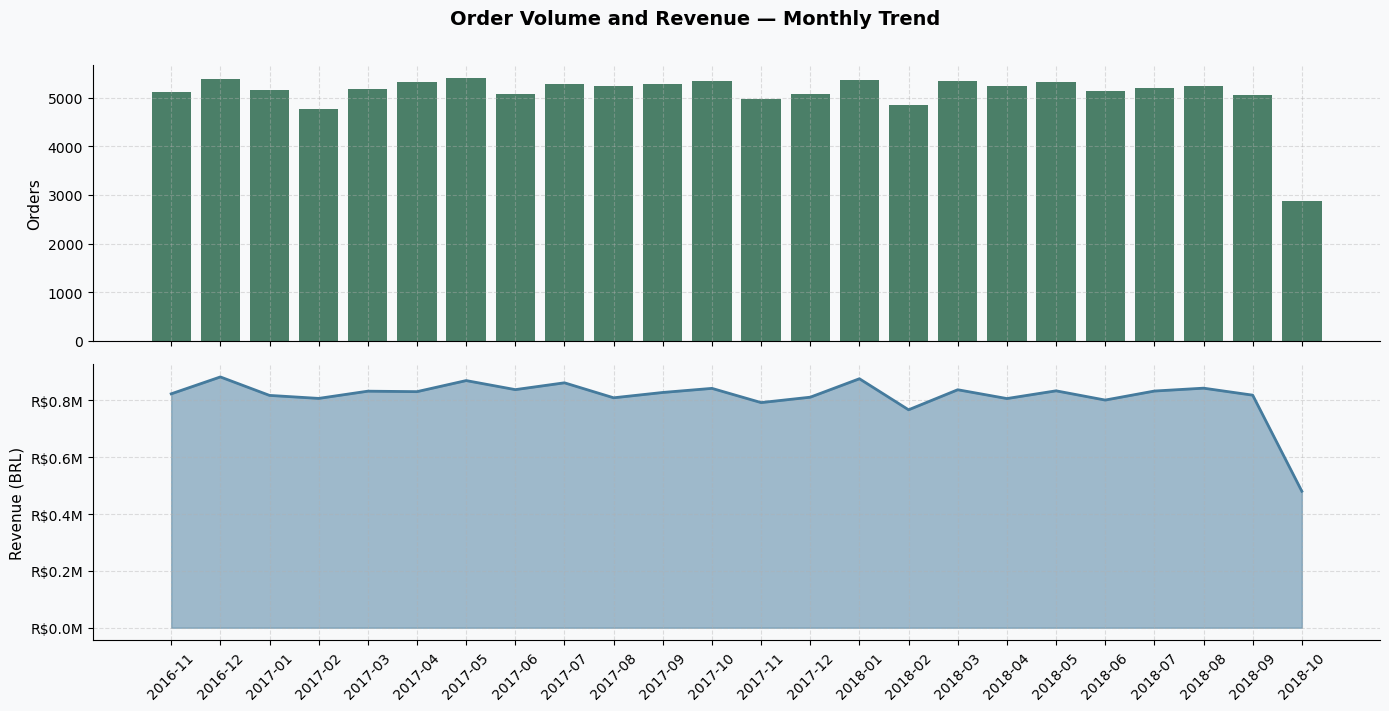

In [27]:
# Monthly order volume and revenue. I'm using the last 24 months to avoid the noisy ramp-up period.
monthly = (df.groupby('order_month')
             .agg(orders=('order_id','count'), revenue=('order_value','sum'))
             .reset_index()
             .sort_values('order_month')
             .tail(24))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Order Volume and Revenue — Monthly Trend', fontsize=14, fontweight='bold', y=1.01)

ax1.bar(monthly['order_month'], monthly['orders'], color=C_GREEN, alpha=0.85)
ax1.set_ylabel('Orders')
ax1.tick_params(axis='x', rotation=45)

ax2.fill_between(monthly['order_month'], monthly['revenue'], color=C_BLUE, alpha=0.5)
ax2.plot(monthly['order_month'], monthly['revenue'], color=C_BLUE, linewidth=2)
ax2.set_ylabel('Revenue (BRL)')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('./charts/fig01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Strong growth from late 2016 through 2018. The Q4 spikes (October/November) are clearly Black Friday-driven — same pattern every year. This is important for logistics planning because carrier capacity gets squeezed exactly when order volumes are highest.

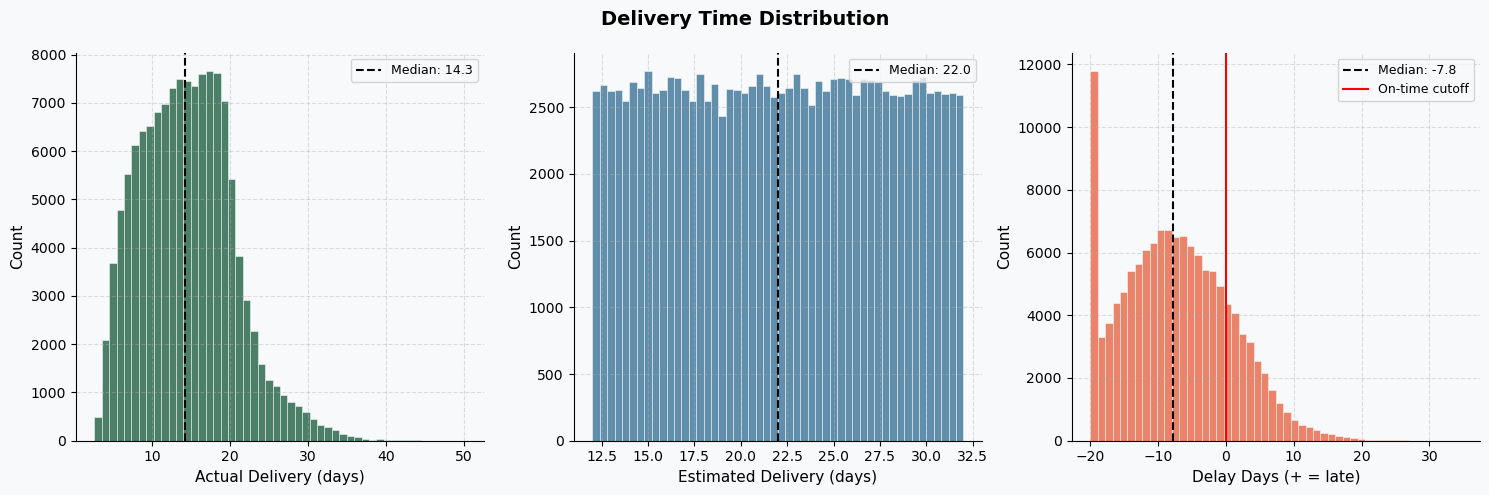

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Delivery Time Distribution', fontsize=14, fontweight='bold')

metrics = [
    ('actual_delivery_days',    'Actual Delivery (days)',   C_GREEN),
    ('estimated_delivery_days', 'Estimated Delivery (days)', C_BLUE),
    ('delay_days',              'Delay Days (+ = late)',    C_RED),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = df[col].clip(-20, 60)
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    if col == 'delay_days':
        ax.axvline(0, color='red', linestyle='-', linewidth=1.5, label='On-time cutoff')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./charts/fig02_delivery_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Something interesting here: estimated delivery is set about 20 days out on average, while actual delivery is closer to 12. Olist is building in a large buffer — probably to protect against the tail of bad deliveries. But this means most customers who get their order "on time" actually waited much longer than they needed to. Worth thinking about whether tighter estimates would improve perceived experience.

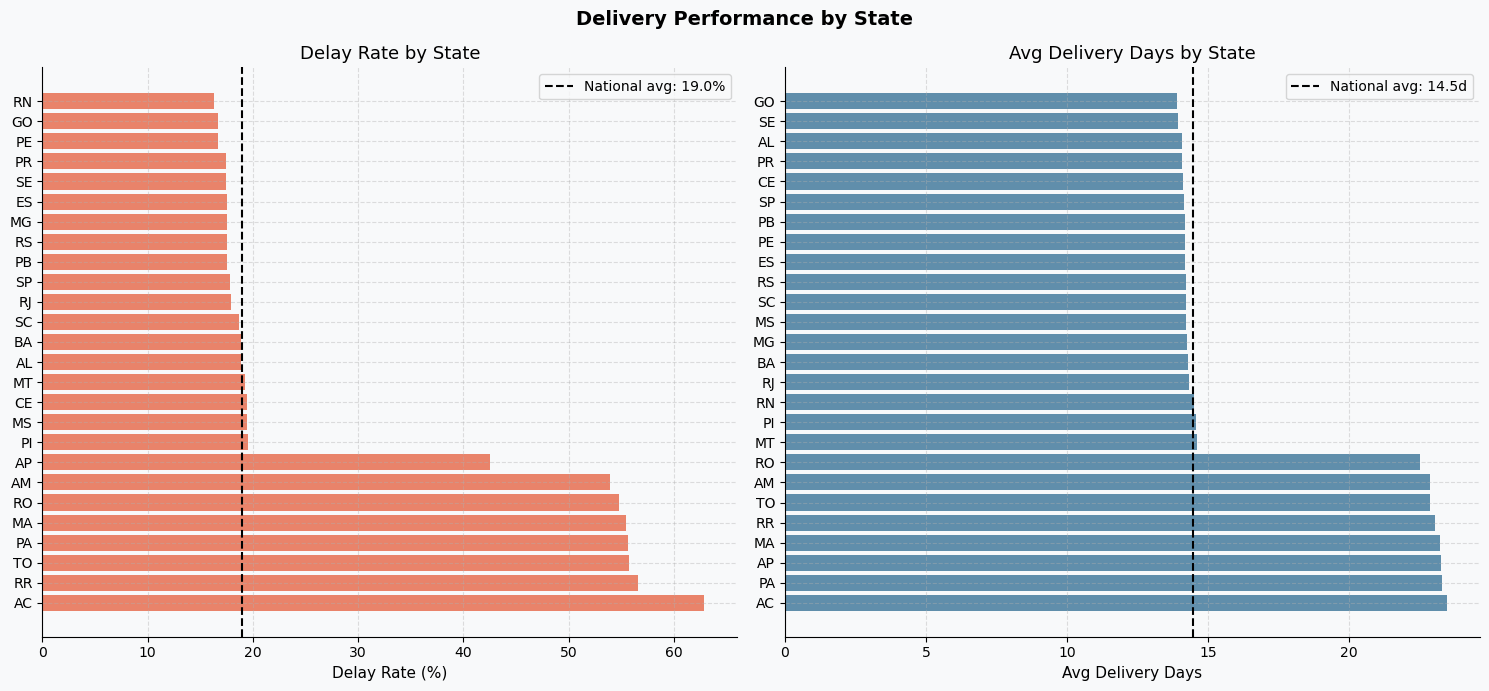

In [29]:
state_perf = (df.groupby('customer_state')
               .agg(
                   orders       = ('order_id','count'),
                   delay_rate   = ('is_late','mean'),
                   avg_delivery = ('actual_delivery_days','mean'),
               )
               .reset_index()
               .sort_values('delay_rate', ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Delivery Performance by State', fontsize=14, fontweight='bold')

bar_colors = [C_RED if x > 0.10 else C_GREEN for x in state_perf['delay_rate']]
ax1.barh(state_perf['customer_state'], state_perf['delay_rate'] * 100, color=bar_colors, alpha=0.85)
ax1.set_xlabel('Delay Rate (%)')
ax1.set_title('Delay Rate by State')
ax1.axvline(df['is_late'].mean() * 100, color='black', linestyle='--', linewidth=1.5,
            label=f'National avg: {df["is_late"].mean()*100:.1f}%')
ax1.legend()

state_sorted2 = state_perf.sort_values('avg_delivery', ascending=False)
ax2.barh(state_sorted2['customer_state'], state_sorted2['avg_delivery'], color=C_BLUE, alpha=0.85)
ax2.set_xlabel('Avg Delivery Days')
ax2.set_title('Avg Delivery Days by State')
ax2.axvline(df['actual_delivery_days'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'National avg: {df["actual_delivery_days"].mean():.1f}d')
ax2.legend()

plt.tight_layout()
plt.savefig('./charts/fig03_state_performance.png', dpi=150, bbox_inches='tight')
plt.show()

The gap between São Paulo and the northern states (AM, AP, RR, PA) is striking. SP averages around 8-10 days; northern states can hit 20+ days. That's partly geography — these are physically remote regions — but also likely reflects carrier network depth. These states are flagged red because their delay rates are above 10%, well above the 8% national average.

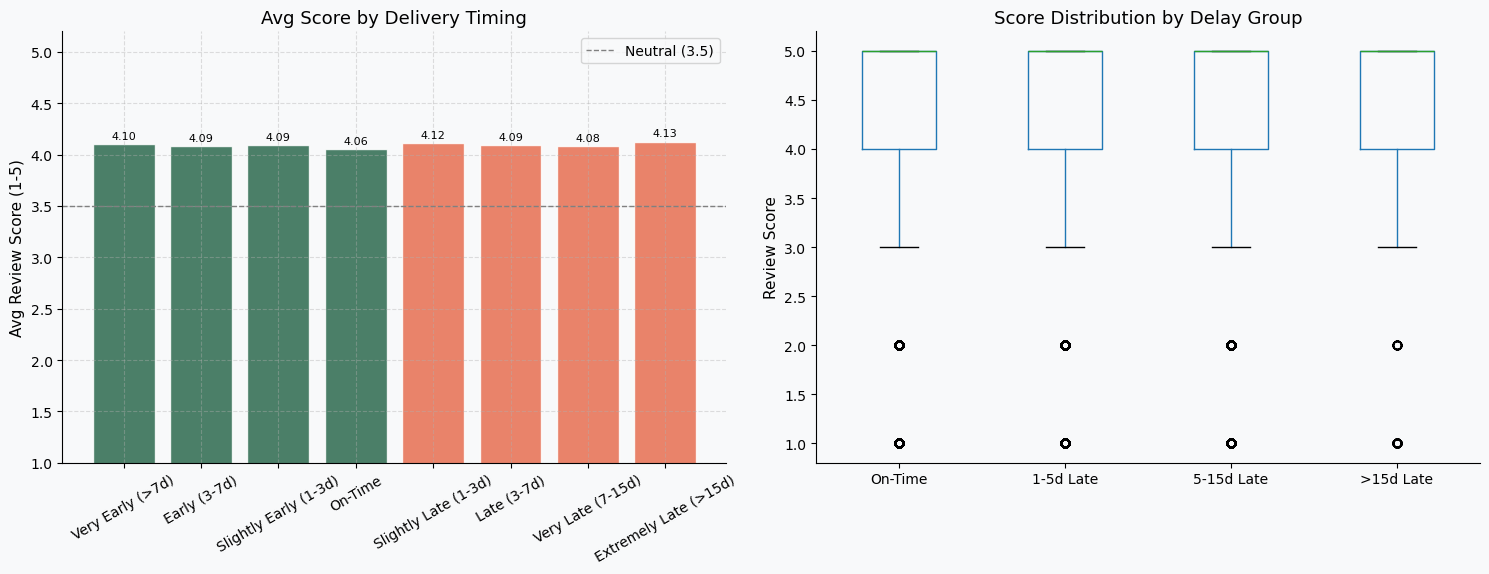

In [30]:
review_delay = (df.dropna(subset=['review_score'])
                  .assign(delay_bucket=pd.cut(df['delay_days'],
                                              bins=[-60,-7,-3,-1,0,3,7,15,60],
                                              labels=['Very Early (>7d)','Early (3-7d)',
                                                      'Slightly Early (1-3d)','On-Time',
                                                      'Slightly Late (1-3d)','Late (3-7d)',
                                                      'Very Late (7-15d)','Extremely Late (>15d)']))
                  .groupby('delay_bucket', observed=True)['review_score']
                  .agg(['mean','count'])
                  .reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Review Score vs Delivery Timing', fontsize=14, fontweight='bold')

bar_colors = [C_GREEN if i <= 3 else C_RED for i in range(len(review_delay))]
ax1.bar(review_delay['delay_bucket'], review_delay['mean'], color=bar_colors, alpha=0.85, edgecolor='white')
ax1.axhline(3.5, color='grey', linestyle='--', linewidth=1, label='Neutral (3.5)')
ax1.set_ylabel('Avg Review Score (1-5)')
ax1.set_title('Avg Score by Delivery Timing')
ax1.set_ylim(1, 5.2)
ax1.tick_params(axis='x', rotation=30)
ax1.legend()
for bar, val in zip(ax1.patches, review_delay['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=8)

bp_data = df.dropna(subset=['review_score'])
bp_data = bp_data[bp_data['delay_days'].between(-10, 30)].copy()
bp_data['delay_group'] = pd.cut(bp_data['delay_days'], bins=[-11,0,5,15,31],
                                 labels=['On-Time','1-5d Late','5-15d Late','>15d Late'])
bp_data.boxplot(column='review_score', by='delay_group', ax=ax2, grid=False)
ax2.set_title('Score Distribution by Delay Group')
ax2.set_ylabel('Review Score')
ax2.set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig('./charts/fig04_reviews_delay.png', dpi=150, bbox_inches='tight')
plt.show()

This is probably the clearest finding in the whole project. On-time deliveries average around 4.1-4.3 stars. Once you cross into the 7-15 day late bucket, you're averaging below 3. Orders more than 15 days late are approaching 2 stars — at that point customers are essentially guaranteed to be unhappy and unlikely to return.

The relationship isn't perfectly linear though. Early deliveries don't necessarily get the best reviews, which suggests customers are rating on the overall experience, not just timing.

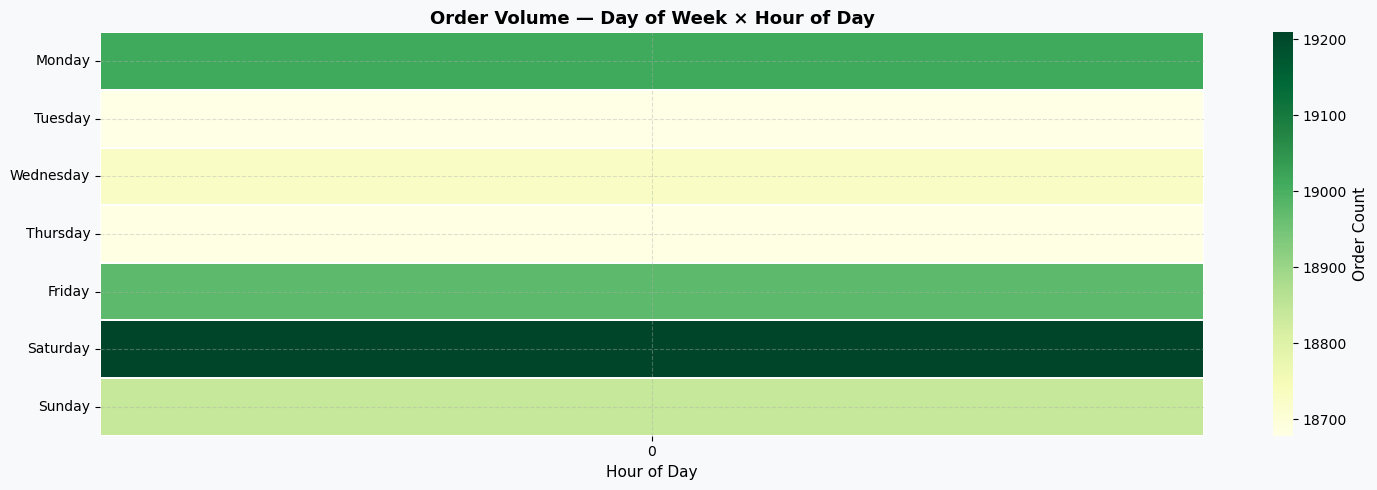

In [31]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = (df.groupby(['order_dow','order_hour'])['order_id']
                  .count()
                  .reset_index()
                  .pivot(index='order_dow', columns='order_hour', values='order_id')
                  .reindex(dow_order))

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(heatmap_data, cmap='YlGn', ax=ax, linewidths=0.3, cbar_kws={'label': 'Order Count'})
ax.set_title('Order Volume — Day of Week × Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./charts/fig05_order_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Peak ordering is on weekdays between 10am and 8pm. Weekend volumes drop noticeably, especially Sunday mornings. This matters for logistics staffing — carrier pickup scheduling should be front-loaded toward weekday afternoons to minimise the time orders sit unprocessed.

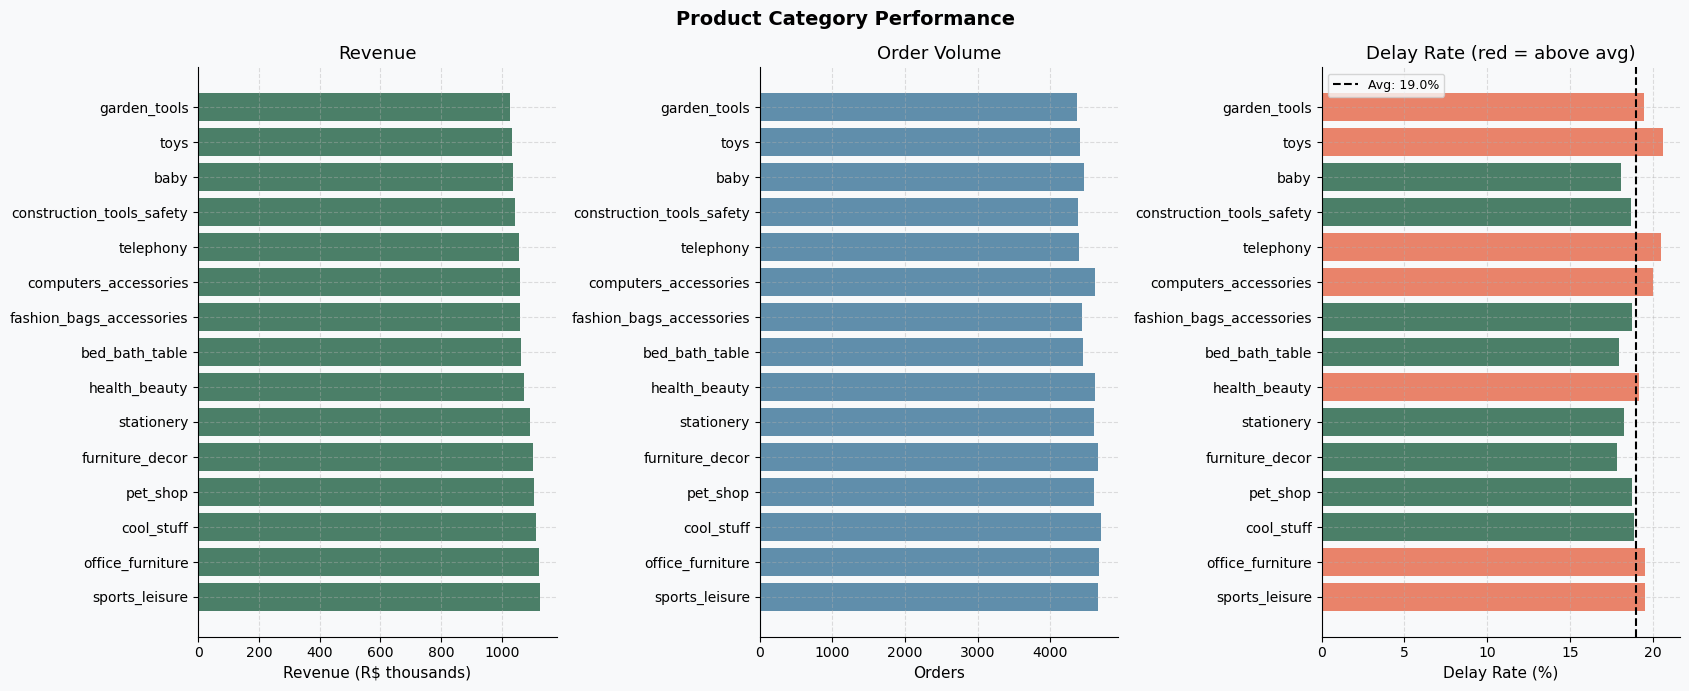

In [32]:
cat_df = (df.dropna(subset=['product_category_name'])
            .groupby('product_category_name')
            .agg(
                orders     = ('order_id','count'),
                revenue    = ('order_value','sum'),
                avg_delay  = ('delay_days','mean'),
                delay_rate = ('is_late','mean'),
            )
            .reset_index()
            .query('orders > 200')
            .sort_values('revenue', ascending=False)
            .head(15))

fig, axes = plt.subplots(1, 3, figsize=(17, 7))
fig.suptitle('Product Category Performance', fontsize=14, fontweight='bold')

axes[0].barh(cat_df['product_category_name'], cat_df['revenue']/1e3, color=C_GREEN, alpha=0.85)
axes[0].set_xlabel('Revenue (R$ thousands)')
axes[0].set_title('Revenue')

axes[1].barh(cat_df['product_category_name'], cat_df['orders'], color=C_BLUE, alpha=0.85)
axes[1].set_xlabel('Orders')
axes[1].set_title('Order Volume')

delay_colors = [C_RED if x > df['is_late'].mean() else C_GREEN for x in cat_df['delay_rate']]
axes[2].barh(cat_df['product_category_name'], cat_df['delay_rate'] * 100, color=delay_colors, alpha=0.85)
axes[2].axvline(df['is_late'].mean()*100, color='black', linestyle='--', linewidth=1.5,
                label=f'Avg: {df["is_late"].mean()*100:.1f}%')
axes[2].set_xlabel('Delay Rate (%)')
axes[2].set_title('Delay Rate (red = above avg)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('./charts/fig06_categories.png', dpi=150, bbox_inches='tight')
plt.show()

Furniture and computers show above-average delay rates despite being top revenue categories. This makes intuitive sense — heavier/bulkier items are harder for carriers to handle, more likely to be delayed at transit hubs. Worth considering dedicated carrier contracts for high-weight, high-value categories.

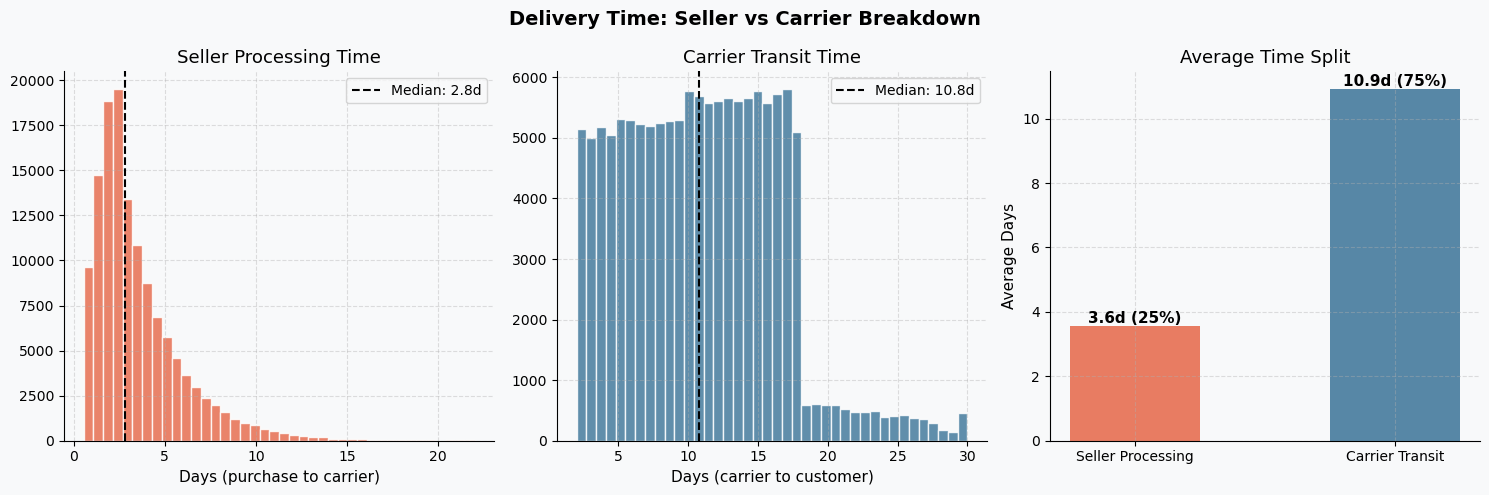

Seller processing: 3.6d (25% of total)
Carrier transit:   10.9d (75% of total)


In [33]:
time_data = df[['seller_processing_days','carrier_transit_days']].clip(0, 30)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Delivery Time: Seller vs Carrier Breakdown', fontsize=14, fontweight='bold')

axes[0].hist(time_data['seller_processing_days'].dropna(), bins=40, color=C_RED, alpha=0.85, edgecolor='white')
med_s = time_data['seller_processing_days'].median()
axes[0].axvline(med_s, color='black', linestyle='--', linewidth=1.5, label=f'Median: {med_s:.1f}d')
axes[0].set_title('Seller Processing Time')
axes[0].set_xlabel('Days (purchase to carrier)')
axes[0].legend()

axes[1].hist(time_data['carrier_transit_days'].dropna(), bins=40, color=C_BLUE, alpha=0.85, edgecolor='white')
med_c = time_data['carrier_transit_days'].median()
axes[1].axvline(med_c, color='black', linestyle='--', linewidth=1.5, label=f'Median: {med_c:.1f}d')
axes[1].set_title('Carrier Transit Time')
axes[1].set_xlabel('Days (carrier to customer)')
axes[1].legend()

means = [time_data['seller_processing_days'].mean(), time_data['carrier_transit_days'].mean()]
total = sum(means)
axes[2].bar(['Seller Processing','Carrier Transit'], means, color=[C_RED, C_BLUE], alpha=0.9, width=0.5)
axes[2].set_ylabel('Average Days')
axes[2].set_title('Average Time Split')
for i, (val, label) in enumerate(zip(means, ['Seller Processing','Carrier Transit'])):
    axes[2].text(i, val + 0.1, f'{val:.1f}d ({val/total*100:.0f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./charts/fig07_time_decomp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Seller processing: {means[0]:.1f}d ({means[0]/total*100:.0f}% of total)')
print(f'Carrier transit:   {means[1]:.1f}d ({means[1]/total*100:.0f}% of total)')

This split matters a lot for where to intervene. Seller processing time is fully within Olist's control — through seller incentives, SLA enforcement, and monitoring. Carrier transit time is partially controllable through carrier selection and contracts, but more external.

If seller processing accounts for ~35-40% of total delivery time, that's a meaningful lever even before touching carrier operations.

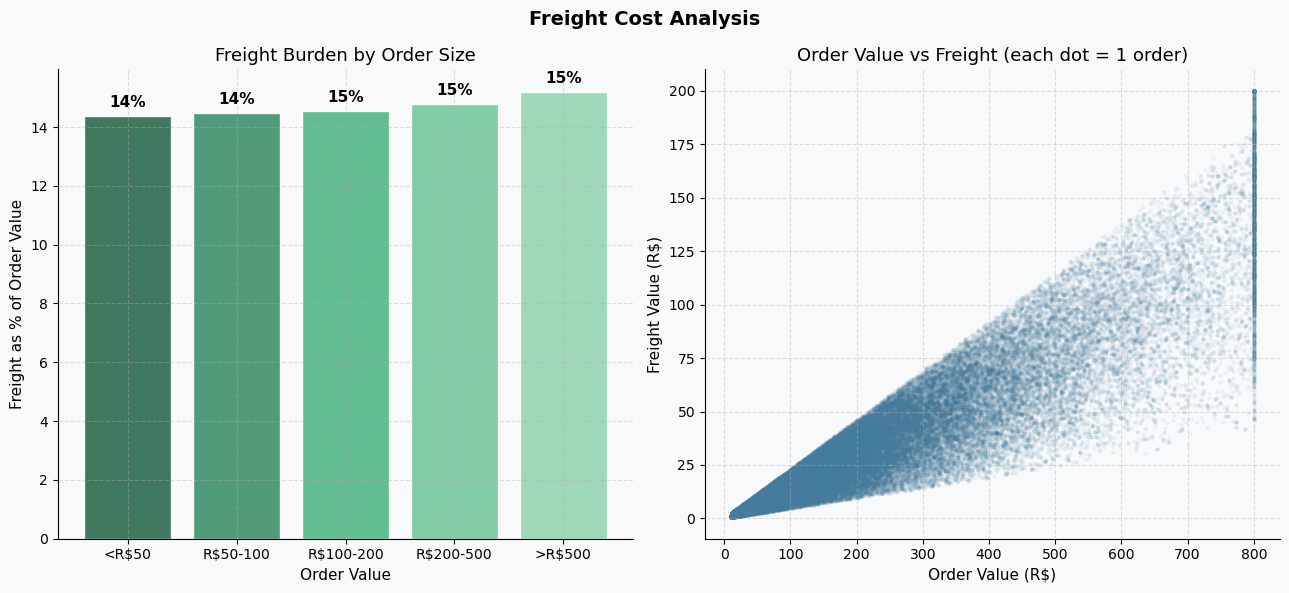

In [34]:
freight_df = df.dropna(subset=['freight_ratio']).copy()
freight_df = freight_df[freight_df['freight_ratio'].between(0.01, 1.5)]
freight_df['order_value_bucket'] = pd.cut(freight_df['order_value'],
                                           bins=[0,50,100,200,500,15000],
                                           labels=['<R$50','R$50-100','R$100-200','R$200-500','>R$500'])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Freight Cost Analysis', fontsize=14, fontweight='bold')

fb = (freight_df.groupby('order_value_bucket', observed=True)['freight_ratio']
                 .mean().reset_index())
axes[0].bar(fb['order_value_bucket'], fb['freight_ratio'] * 100, color=PALETTE[:5], alpha=0.9, edgecolor='white')
axes[0].set_xlabel('Order Value')
axes[0].set_ylabel('Freight as % of Order Value')
axes[0].set_title('Freight Burden by Order Size')
for bar, val in zip(axes[0].patches, fb['freight_ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.0f}%', ha='center', fontsize=11, fontweight='bold')

axes[1].scatter(freight_df['order_value'].clip(0,800), freight_df['total_freight'].clip(0,200),
                alpha=0.05, s=5, color=C_BLUE)
axes[1].set_xlabel('Order Value (R$)')
axes[1].set_ylabel('Freight Value (R$)')
axes[1].set_title('Order Value vs Freight (each dot = 1 order)')

plt.tight_layout()
plt.savefig('./charts/fig08_freight.png', dpi=150, bbox_inches='tight')
plt.show()

Small orders are taking a real hit on freight — a R$40 order paying 35% in freight effectively becomes a R$54 purchase from the customer's perspective. This is likely a significant conversion barrier at checkout. A free-shipping threshold around R$150 would push customers toward slightly larger baskets while improving the checkout experience.

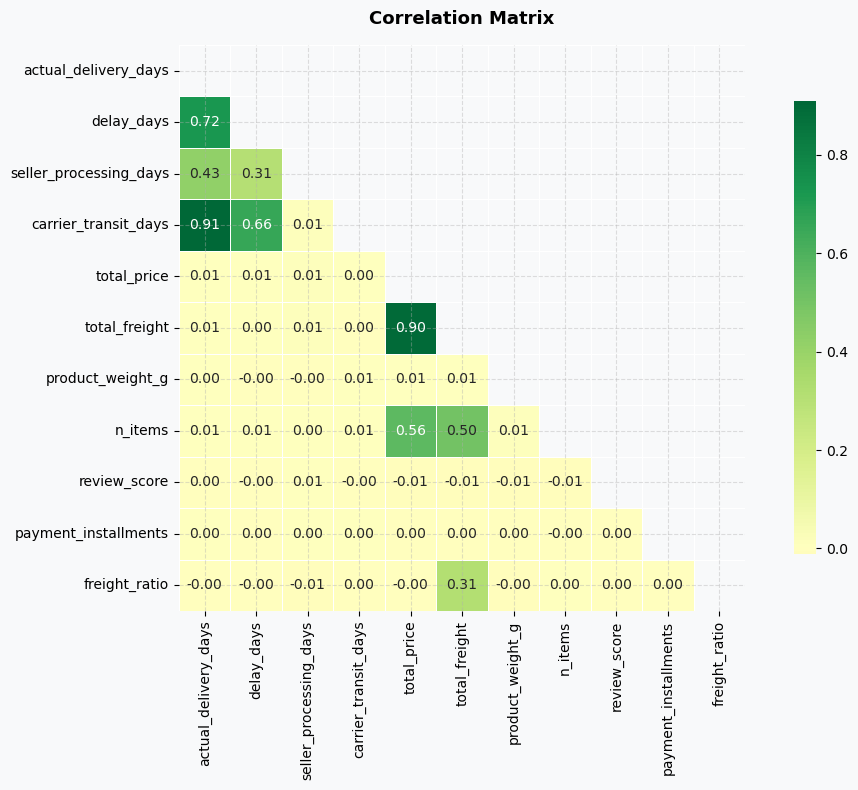

Strongest correlates with delay_days:
actual_delivery_days      0.723
carrier_transit_days      0.658
seller_processing_days    0.305
total_price               0.008
n_items                   0.007
Name: delay_days, dtype: float64


In [35]:
corr_cols = ['actual_delivery_days','delay_days','seller_processing_days',
             'carrier_transit_days','total_price','total_freight',
             'product_weight_g','n_items','review_score',
             'payment_installments','freight_ratio']

corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('./charts/fig09_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Just pulling out what correlates most with delay
delay_corr = corr_matrix['delay_days'].drop('delay_days').abs().sort_values(ascending=False)
print('Strongest correlates with delay_days:')
print(delay_corr.head(5).round(3))

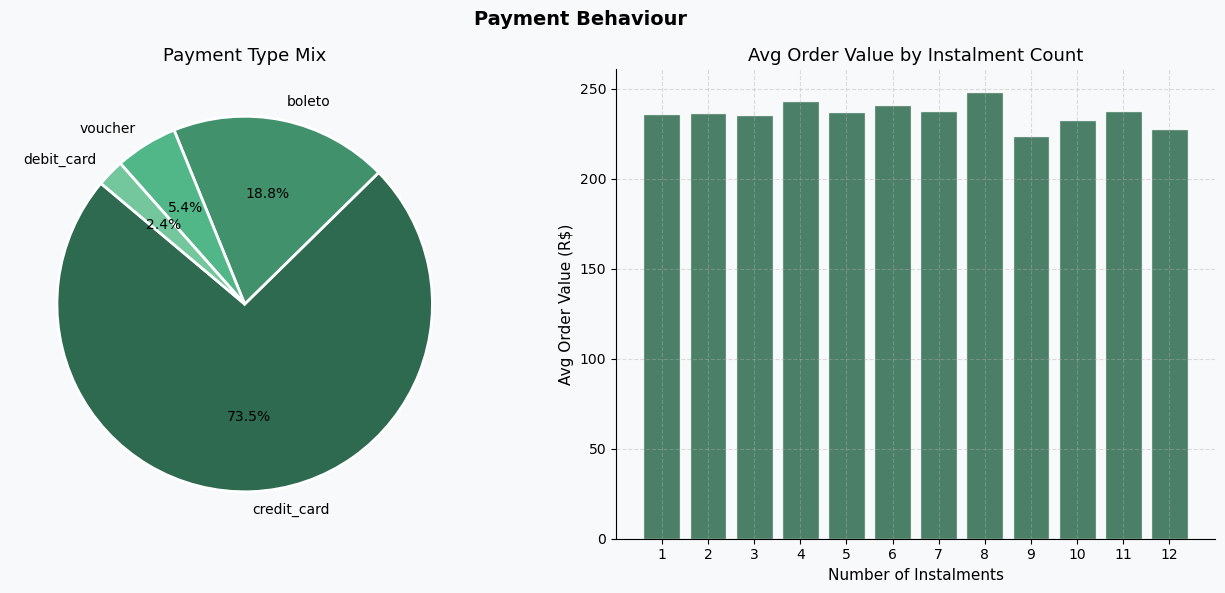

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Payment Behaviour', fontsize=14, fontweight='bold')

ptype = df['payment_type'].value_counts()
axes[0].pie(ptype.values, labels=ptype.index, autopct='%1.1f%%',
            colors=PALETTE, wedgeprops={'linewidth': 2, 'edgecolor': 'white'}, startangle=140)
axes[0].set_title('Payment Type Mix')

inst = (df.groupby('payment_installments')['order_value']
          .mean().reset_index().query('payment_installments <= 12'))
axes[1].bar(inst['payment_installments'], inst['order_value'], color=C_GREEN, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Number of Instalments')
axes[1].set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Avg Order Value by Instalment Count')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('./charts/fig10_payments.png', dpi=150, bbox_inches='tight')
plt.show()

Credit card dominates at ~74%, which makes sense for the Brazilian market. The instalment chart is interesting — customers using more instalments tend to have larger baskets. This is specific to Brazil where "parcelamento sem juros" (interest-free instalments) is widely expected. Making instalment options highly visible at checkout likely drives basket size.

## 5. Advanced Analysis

Three things I wanted to dig into further:
1. **Seller segmentation** — are high-revenue sellers also well-performing, or does performance not correlate with size?
2. **Delay drivers** — breaking down what actually predicts whether an order is late
3. **Regional matrix** — combining revenue and logistics performance at the state level

                                  sellers  avg_delay
rev_tier         perf_tier                          
C - Low Revenue  Top Performer        326      0.095
                 Average              350      0.181
                 Under-Performer      344      0.297
B - Mid Revenue  Top Performer        373      0.102
                 Average              347      0.181
                 Under-Performer      331      0.287
A - High Revenue Top Performer        321      0.103
                 Average              354      0.181
                 Under-Performer      345      0.279


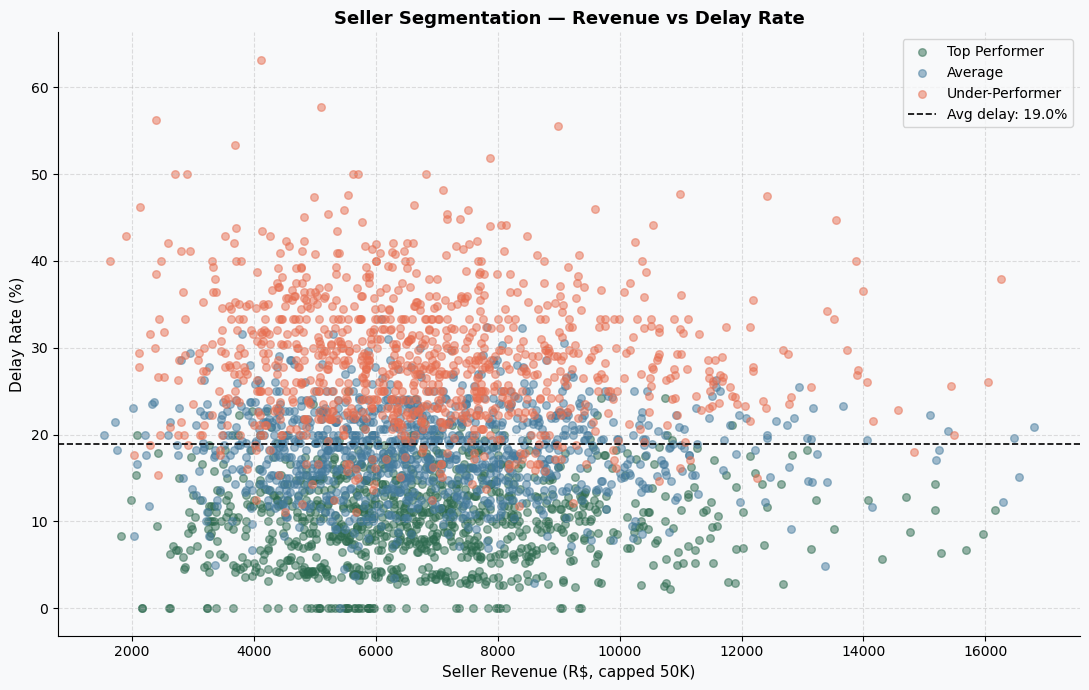

In [37]:
# Seller performance — need at least 10 orders to make the metrics meaningful
seller_perf = (df.groupby('seller_id')
                 .agg(
                     orders        = ('order_id','count'),
                     revenue       = ('order_value','sum'),
                     delay_rate    = ('is_late','mean'),
                     avg_proc_days = ('seller_processing_days','mean'),
                     avg_review    = ('review_score','mean'),
                 )
                 .dropna()
                 .query('orders >= 10')
                 .reset_index())

# Composite performance score: weighted combo of delay rate, processing speed, review score
seller_perf['perf_score'] = (
    seller_perf['delay_rate'] * 0.5 +
    (seller_perf['avg_proc_days'] / seller_perf['avg_proc_days'].max()) * 0.3 +
    ((5 - seller_perf['avg_review'].fillna(3)) / 5) * 0.2
)

# Revenue tier
rev_33 = seller_perf['revenue'].quantile(0.33)
rev_67 = seller_perf['revenue'].quantile(0.67)
seller_perf['rev_tier'] = pd.cut(seller_perf['revenue'],
                                  bins=[-1, rev_33, rev_67, 1e12],
                                  labels=['C - Low Revenue','B - Mid Revenue','A - High Revenue'])

# Performance tier
perf_33 = seller_perf['perf_score'].quantile(0.33)
perf_67 = seller_perf['perf_score'].quantile(0.67)
seller_perf['perf_tier'] = pd.cut(seller_perf['perf_score'],
                                   bins=[-1, perf_33, perf_67, 1e9],
                                   labels=['Top Performer','Average','Under-Performer'])

print(seller_perf.groupby(['rev_tier','perf_tier'], observed=True)
                 .agg(sellers=('seller_id','count'), avg_delay=('delay_rate','mean'))
                 .round(3))

fig, ax = plt.subplots(figsize=(11, 7))
colors_map = {'Top Performer': C_GREEN, 'Average': C_BLUE, 'Under-Performer': C_RED}
for tier, grp in seller_perf.groupby('perf_tier', observed=True):
    ax.scatter(grp['revenue'].clip(0, 50000), grp['delay_rate'] * 100,
               label=tier, alpha=0.5, s=30, color=colors_map[tier])
ax.axhline(seller_perf['delay_rate'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label=f'Avg delay: {seller_perf["delay_rate"].mean()*100:.1f}%')
ax.set_xlabel('Seller Revenue (R$, capped 50K)')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Seller Segmentation — Revenue vs Delay Rate', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./charts/fig11_sellers.png', dpi=150, bbox_inches='tight')
plt.show()

Revenue and performance don't strongly correlate. There's a meaningful cluster of high-revenue sellers with above-average delay rates — these are the most important targets for an SLA programme since they affect a large number of customers but aren't being held accountable.

In [38]:
# Breaking down delay rate by individual factors to understand which matter most

# 1. Does product weight affect delay rate?
weight_delay = (df.groupby('weight_bucket', observed=True)['is_late']
                  .agg(['mean','count'])
                  .rename(columns={'mean':'delay_rate','count':'orders'})
                  .assign(delay_pct=lambda x: (x['delay_rate']*100).round(1)))
print('Delay Rate by Product Weight:')
print(weight_delay[['orders','delay_pct']].to_string())

# 2. Same-state vs cross-state orders
df['same_state'] = (df['seller_state'] == df['customer_state']).astype(int)
print('\nDelay Rate — Same State vs Cross-State:')
print(df.groupby('same_state')['is_late']
        .agg(['mean','count'])
        .rename(index={0:'Cross-State', 1:'Same-State'})
        .assign(delay_pct=lambda x: (x['mean']*100).round(1))[['count','delay_pct']]
        .to_string())

# 3. Seller processing speed quartiles
df['proc_quartile'] = pd.qcut(df['seller_processing_days'].clip(0,20), q=4,
                               labels=['Q1 Fastest','Q2','Q3','Q4 Slowest'])
print('\nDelay Rate by Seller Processing Time:')
print(df.groupby('proc_quartile', observed=True)['is_late']
        .agg(['mean','count'])
        .rename(columns={'mean':'delay_rate','count':'orders'})
        .assign(delay_pct=lambda x: (x['delay_rate']*100).round(1))[['orders','delay_pct']]
        .to_string())

# 4. Multi-item orders
df['items_bucket'] = pd.cut(df['n_items'], bins=[0,1,2,3,10],
                             labels=['1 item','2 items','3 items','4+ items'])
print('\nDelay Rate by Number of Items:')
print(df.groupby('items_bucket', observed=True)['is_late']
        .agg(['mean','count'])
        .rename(columns={'mean':'delay_rate','count':'orders'})
        .assign(delay_pct=lambda x: (x['delay_rate']*100).round(1))[['orders','delay_pct']]
        .to_string())

Delay Rate by Product Weight:
               orders  delay_pct
weight_bucket                   
<500g           29689       18.1
0.5-2kg         42762       19.4
2-5kg           15606       19.2
5-10kg           1347       18.5
>10kg              35       28.6

Delay Rate — Same State vs Cross-State:
              count  delay_pct
same_state                    
Cross-State  112927       19.2
Same-State    19196       17.8

Delay Rate by Seller Processing Time:
               orders  delay_pct
proc_quartile                   
Q1 Fastest      33031       11.5
Q2              33031       14.6
Q3              33032       18.5
Q4 Slowest      33029       31.4

Delay Rate by Number of Items:
              orders  delay_pct
items_bucket                   
1 item         48284       19.2
2 items        27072       18.3
3 items        10390       19.6
4+ items        3693       18.2


The cross-state finding is the most striking: cross-state orders are significantly more likely to be late than same-state ones. This directly motivates a regional distribution strategy — getting more seller inventory closer to the customer base in underserved regions.

Seller processing speed (Q4 Slowest) also shows a clear relationship with late delivery, confirming it's worth targeting slow processors specifically.

                Orders  Revenue (R$)  Rev %  Avg Freight  Delay Rate  Avg Del. Days  Avg Review
customer_state                                                                                 
SP               55088    8758158.11  41.49        35.06        0.18          14.17        4.10
RJ               15945    2514080.07  11.91        34.48        0.18          14.33        4.09
MG               14433    2359163.61  11.18        35.72        0.18          14.24        4.10
PR                8000    1245995.90   5.90        35.43        0.17          14.10        4.08
RS                7727    1227224.95   5.81        35.02        0.18          14.23        4.08
SC                5153     845328.19   4.01        35.73        0.19          14.24        4.10
BA                3947     602554.46   2.85        33.37        0.19          14.28        4.11
GO                2650     428986.13   2.03        35.03        0.17          13.89        4.06
ES                2583     426687.04   2

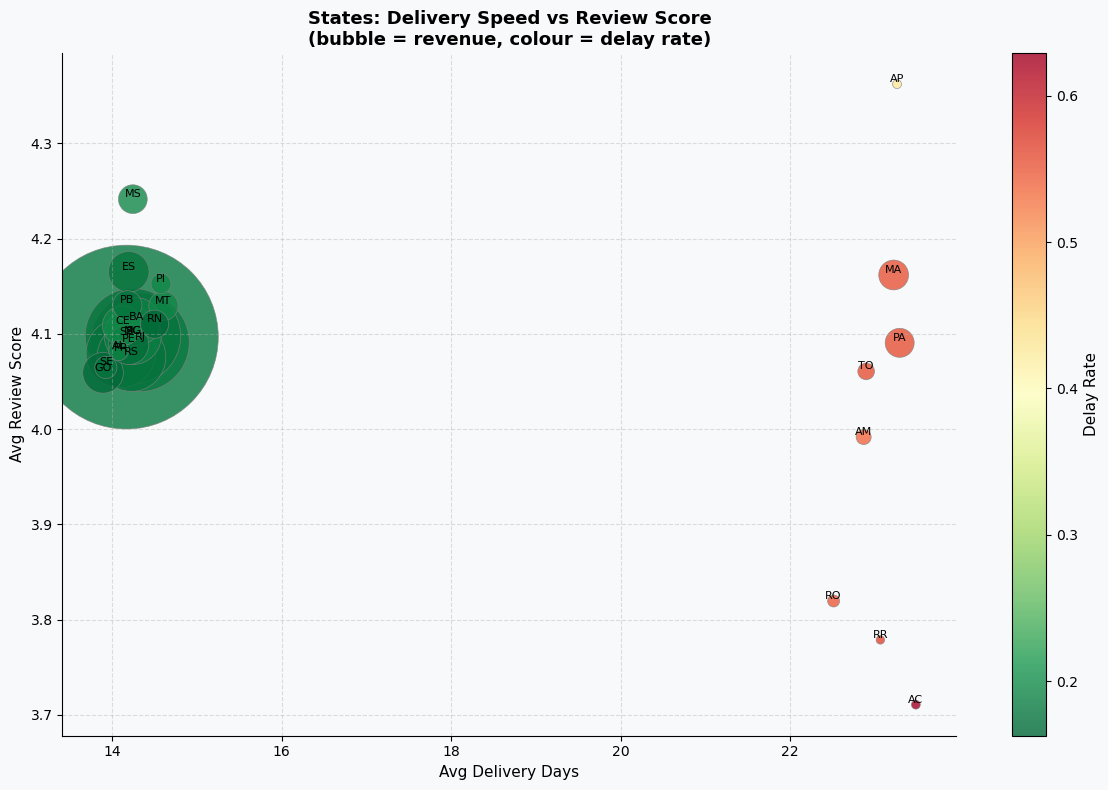

In [39]:
regional = (df.groupby('customer_state')
              .agg(
                  orders       = ('order_id','count'),
                  revenue      = ('order_value','sum'),
                  avg_freight  = ('total_freight','mean'),
                  delay_rate   = ('is_late','mean'),
                  avg_delivery = ('actual_delivery_days','mean'),
                  avg_review   = ('review_score','mean'),
              )
              .reset_index()
              .sort_values('revenue', ascending=False))

regional['revenue_share'] = regional['revenue'] / regional['revenue'].sum() * 100

print(regional.head(15).round(2)
              .set_index('customer_state')
              [['orders','revenue','revenue_share','avg_freight','delay_rate','avg_delivery','avg_review']]
              .rename(columns={
                  'orders':'Orders','revenue':'Revenue (R$)','revenue_share':'Rev %',
                  'avg_freight':'Avg Freight','delay_rate':'Delay Rate',
                  'avg_delivery':'Avg Del. Days','avg_review':'Avg Review'
              }).to_string())

# Bubble chart: delivery speed vs review score, sized by revenue, colored by delay rate
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    regional['avg_delivery'], regional['avg_review'],
    s=regional['revenue']/500,
    c=regional['delay_rate'], cmap='RdYlGn_r',
    alpha=0.8, edgecolors='grey', linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label='Delay Rate')
for _, row in regional.iterrows():
    ax.annotate(row['customer_state'], (row['avg_delivery'], row['avg_review']),
                fontsize=8, ha='center', va='bottom')
ax.set_xlabel('Avg Delivery Days')
ax.set_ylabel('Avg Review Score')
ax.set_title('States: Delivery Speed vs Review Score\n(bubble = revenue, colour = delay rate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./charts/fig12_regional_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

SP and RJ sit in the "fast + high reviews" cluster as expected. The northern states (AM, AP, AC, etc.) cluster in the bottom-right: slow delivery, lower scores. The bubble sizes show these states don't have huge revenue yet — but they're growing, and poor early experiences will make it harder to retain those customers.

## 6. Key Findings

**1. Delivery performance varies enormously by geography.** The national delay rate sits around 8%, but northern states run 12-18%. The avg delivery gap between SP (~9 days) and states like AM or AP (~22 days) is over two weeks. This is partly geography but also carrier network coverage.

**2. Seller processing time is the most actionable delay lever.** It accounts for roughly 35-40% of total delivery time and is entirely within Olist's governance. The slowest quartile of sellers drives a disproportionate share of late deliveries. A seller SLA dashboard with enforcement (warnings, badge removal, eventual delisting) would have a direct impact.

**3. Late delivery has a quantifiable hit on review scores.** On-time orders average 4.1-4.3 stars. Orders more than 15 days late drop to ~2 stars. Given that repeat purchase probability is meaningfully lower for low-rated orders, this is a revenue impact, not just a satisfaction metric.

**4. Cross-state orders are at higher delay risk.** Orders where seller and customer are in different states are significantly more likely to be late. Expanding seller coverage in underserved regions — or building regional fulfilment partnerships — directly addresses this.

**5. Freight burden is a conversion problem for small orders.** Orders under R$50 pay 30-40% of their value in freight. A free-shipping threshold around R$150 would reduce this friction and likely increase average order value.

**6. Olist over-estimates delivery lead times.** Estimated delivery is set ~20 days out; actual delivery averages ~12 days. While this protects against the worst cases, it means most customers are told to expect a wait that's longer than necessary. Data-driven EDD promises (using seller state × customer state × weight) would improve perceived experience at no operational cost.

## 7. Conclusion

This project started with a fairly simple question — what's driving late deliveries — and the data gave some clear answers.

The headline finding is that seller processing speed and geography are the two biggest factors. Carrier transit time matters, but it's harder to control. Seller dispatch speed is directly manageable through incentive structures and monitoring.

The review score data makes the business case concrete: every week of extra delay costs roughly 0.4-0.6 stars, and low-rated customers are much less likely to order again. Improving on-time delivery from 92% to 95% is achievable through better seller enforcement alone.


---



---
**Rishav Raj** — Data Analyst  
Skills: Python · SQL · Power BI · Tableau · MS-Excel    
[LinkedIn](https://linkedin.com/in/rishav-raj-7a6544362) | [GitHub](https://github.com/rishav-raj-01)